# EDA 11: Supplementary Metabolomics

## Purpose

Metabolites are small chemicals that cells use or produce while making energy, DNA, proteins, and cell membranes. Examples include citrate, lactate, AMP, and alpha-ketoglutarate. Metabolomics gives a snapshot of what the cell is doing chemically, but it does not directly identify which gene caused that state.

This table is from a 2019-era source and remains supporting context outside the release-matched core score.

## Column dictionary

| Column | Plain-language meaning | Use in this project |
| --- | --- | --- |
| `model_id` | DepMap cell-line identifier. | Only automatic model join key. |
| `CCLE_ID` | CCLE cell-line label. | Identity cross-check only. |
| Every metabolite column | Relative normalised abundance of one small chemical. | Metabolic-state context for later gene-pair explanations. |

The values are relative measurements on the supplied processed scale. They are not absolute chemical concentrations.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns',100); pd.set_option('display.max_rows',100)
sns.set_theme(style='whitegrid',context='notebook')
def find_root(start):
    for candidate in (start,*start.parents):
        if (candidate/'data'/'depmap_24Q4'/'architecture'/'model_master.csv').exists(): return candidate
    raise FileNotFoundError('Run inside the az-team25 repository.')
PROJECT_ROOT=find_root(Path.cwd().resolve()); DATA=PROJECT_ROOT/'data'/'depmap_24Q4'
master=pd.read_csv(DATA/'architecture'/'model_master.csv',low_memory=False)

met=pd.read_csv(DATA/'supplementary'/'metabolomics_model.csv',low_memory=False); features=met.columns[2:].tolist()
print(f'{len(met):,} rows, {met.model_id.nunique():,} models, {len(features):,} metabolites'); display(met.iloc[:3,:10])

926 rows, 926 models, 225 metabolites


,model_id,CCLE_ID,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate
0,ACH-000698,DMS53_LUNG,6.112727,6.034198,5.896896,6.000532,5.513618,5.868529,5.977177,5.693074
1,ACH-000489,SW1116_LARGE_INTESTINE,5.577413,5.727045,5.111468,6.073250,5.802494,5.824473,5.888821,5.768379
2,ACH-000431,NCIH1694_LUNG,5.886398,5.574881,5.541259,5.848375,5.665026,5.875548,5.894904,5.839640


## 1. Identity, duplicate models, and coverage

Two models have repeated rows. We display those records and use an explicit model-level median only for later descriptive plots.

In [2]:
duplicates=met.loc[met['model_id'].duplicated(keep=False)].sort_values('model_id'); display(duplicates[['model_id','CCLE_ID']])
audit=pd.DataFrame([{'rows':len(met),'unique_models':met.model_id.nunique(),'duplicated_rows':int(met.model_id.duplicated(keep=False).sum()),'models_not_in_master':len(set(met.model_id)-set(master.model_id)),'master_coverage_pct':100*met.model_id.nunique()/len(master)}]); display(audit)
model_met=met.groupby('model_id',as_index=False)[features].median().merge(master[['model_id','oncotree_lineage']],on='model_id',how='left',validate='one_to_one')

,model_id,CCLE_ID


,rows,unique_models,duplicated_rows,models_not_in_master,master_coverage_pct
0,926,926,0,0,43.990499


### What this means for the project

Repeated measurements do not create extra cell lines. The original rows remain available, while the median is clearly labelled as a descriptive reducer. A later feature pipeline must either select a justified sample or report sensitivity to this reducer.

## 2. Missingness, variation, and familiar metabolites

We inspect which chemicals were measured reliably and how their levels vary across models.

,count,mean,std,min,25%,50%,75%,max
mean,225.0,5.876956,0.069117,5.547092,5.838120,5.890457,5.919370,6.019976
median,225.0,5.887418,0.028273,5.831947,5.865738,5.884087,5.905418,5.974675
sd,225.0,0.372885,0.135175,0.153447,0.288635,0.355428,0.425417,1.347271
missing_pct,225.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,metabolite,mean,median,sd,missing_pct
115,1-methylnicotinamide,5.827489,5.885096,1.347271,0.0
100,acetylcholine,5.673505,5.924425,0.913549,0.0
50,taurodeoxycholate/taurochenodeoxycholate,5.547092,5.865328,0.858413,0.0
51,phosphocreatine,5.713352,5.901217,0.777783,0.0
110,2-deoxycytidine,5.870411,5.905195,0.717824,0.0
129,palmitoylcarnitine,5.969350,5.910287,0.642511,0.0
26,hypoxanthine,5.924594,5.926418,0.639388,0.0
130,stearoylcarnitine,5.971234,5.940314,0.593078,0.0
131,oleylcarnitine,5.969135,5.907178,0.592365,0.0
94,N-carbamoyl-beta-alanine,5.997571,5.942004,0.592347,0.0


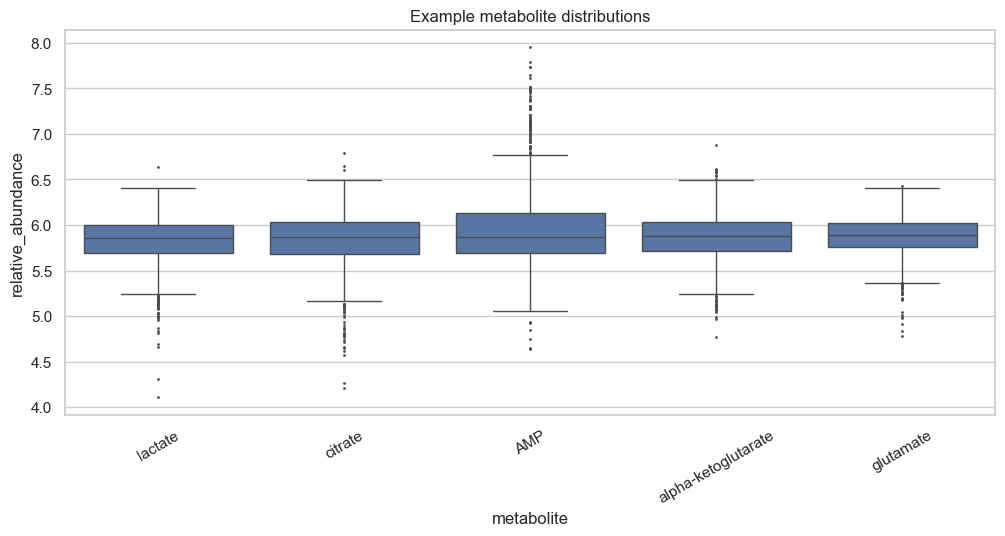

In [3]:
values=model_met[features]
summary=pd.DataFrame({'metabolite':features,'mean':values.mean().values,'median':values.median().values,'sd':values.std().values,'missing_pct':100*values.isna().mean().values})
display(summary[['mean','median','sd','missing_pct']].describe().T); display(summary.nlargest(25,'sd'))
examples=[c for c in ['lactate','citrate','AMP','alpha-ketoglutarate','glutamate','glucose','succinate'] if c in features]
if examples:
    long=model_met[['model_id',*examples]].melt('model_id',var_name='metabolite',value_name='relative_abundance')
    plt.figure(figsize=(12,5)); sns.boxplot(data=long,x='metabolite',y='relative_abundance',fliersize=1); plt.xticks(rotation=30); plt.title('Example metabolite distributions'); plt.show()

### What this means for the project

High lactate can be consistent with strong glycolytic activity, while citrate and alpha-ketoglutarate belong to central energy metabolism. These are clues about cell state, not proof that a submitted gene pair controls that pathway.

## 3. Broad metabolic structure and lineage

Principal component analysis (PCA) compresses many correlated metabolite measurements into a few broad patterns. It helps reveal outliers and lineage structure but does not name a biological pathway by itself.

PC1 variance: 21.0%; PC2 variance: 9.7%


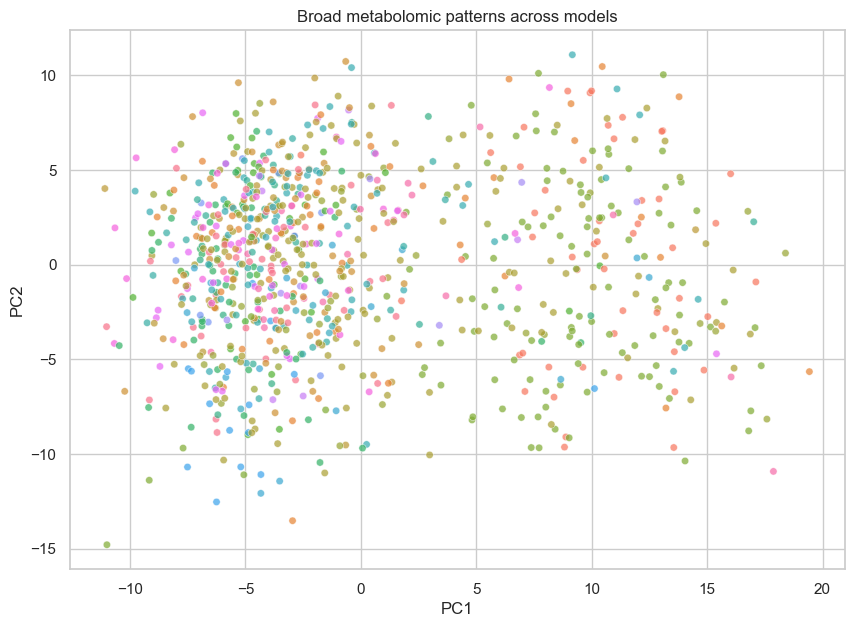

In [4]:
complete=values.loc[:,values.notna().mean().ge(0.8)].copy(); complete=complete.fillna(complete.median())
scaled=(complete-complete.mean())/complete.std(ddof=0).replace(0,1)
u,s,vt=np.linalg.svd(scaled.to_numpy(),full_matrices=False); scores=u[:,:2]*s[:2]
pca=pd.DataFrame({'model_id':model_met.model_id,'PC1':scores[:,0],'PC2':scores[:,1],'oncotree_lineage':model_met.oncotree_lineage})
variance=(s**2)/(s**2).sum()
print(f'PC1 variance: {variance[0]:.1%}; PC2 variance: {variance[1]:.1%}')
plt.figure(figsize=(10,7)); sns.scatterplot(data=pca,x='PC1',y='PC2',hue='oncotree_lineage',s=28,alpha=.7,legend=False); plt.title('Broad metabolomic patterns across models'); plt.show()

### What this means for the project

Models close together on the PCA plot have broadly similar measured metabolic states. Separation can reflect lineage, culture conditions, or biology. We will not use these components as an unexplained pair score.

## Decisions carried forward

- Keep metabolomics outside the release-matched core score and label its 2019 provenance.
- Preserve duplicate source rows; use a stated reducer only for model-level exploration.
- Report per-metabolite missingness and model denominator.
- Use named metabolites and pathway knowledge only as supporting explanations after a pair is identified.
- Treat PCA as an EDA/outlier tool, not biological proof or a hidden score.